Load Featured Dataset

In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv("../data/processed/train_featured.csv")

print(train.shape)

(590540, 360)


Split Features & Target

In [5]:
X = train.drop("isFraud", axis=1)
y = train["isFraud"]

Scaling

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scalling completed.")

Scalling completed.


Save Scaler

In [7]:
import pickle

pickle.dump(scaler ,open("../models/scaler.pkl", "wb"))
print("Scaler saved.")

Scaler saved.


Train Test Split

In [8]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(472432, 359)
(118108, 359)


Train Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Random Forest Training Completed")

Random Forest Training Completed


Prediction

In [16]:
y_pred = rf.predict(X_test)

Evaluation

In [18]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.88      0.93    113866
           1       0.19      0.74      0.30      4242

    accuracy                           0.87    118108
   macro avg       0.59      0.81      0.61    118108
weighted avg       0.96      0.87      0.91    118108



Save Model

In [19]:
import pickle 

pickle.dump(rf, open("../models/random_forest.pkl", "wb"))
print("Model saved.")

Model saved.


Train XGBoost (First)

In [31]:
from xgboost import XGBClassifier

xgb_1 = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    scale_pos_weight=1,
    random_state=42,
)

xgb_1.fit(X_train, y_train)

print("XGBoost Training Completed")

XGBoost Training Completed


Evaluate

In [32]:
y_pred_xgb = xgb_1.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113866
           1       0.93      0.53      0.68      4242

    accuracy                           0.98    118108
   macro avg       0.96      0.76      0.83    118108
weighted avg       0.98      0.98      0.98    118108



XGBoost (Tuned)

In [26]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=150,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=30,
    random_state=42
)

xgb.fit(X_train, y_train)

print("Improved XGBoost trained")

Improved XGBoost trained


Evalute

In [27]:
y_pred_xgb = xgb.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.91      0.95    113866
           1       0.25      0.81      0.39      4242

    accuracy                           0.91    118108
   macro avg       0.62      0.86      0.67    118108
weighted avg       0.97      0.91      0.93    118108



Save Both Models

In [33]:
#XGBoost (Tuned)
pickle.dump(xgb, open("../models/xgboost_high_recall.pkl", "wb"))

#XGBoost(first)
pickle.dump(xgb_1, open("../models/xgboost_balanced.pkl", "wb"))
print("XGBoost models saved.")


XGBoost models saved.


Train LightGBM

In [34]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimatitors=200,
    learning_rate=0.05,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

lgb.fit(X_train, y_train)

print("LightGBM trained")

LightGBM trained


Prediction

In [35]:
y_pred_lgb = lgb.predict(X_test)

d:\Fraud-Detection-System\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Evaluation

In [36]:
print(classification_report(y_test, y_pred_lgb))

              precision    recall  f1-score   support

           0       0.99      0.87      0.93    113866
           1       0.19      0.79      0.31      4242

    accuracy                           0.87    118108
   macro avg       0.59      0.83      0.62    118108
weighted avg       0.96      0.87      0.91    118108



Save Model

In [37]:
pickle.dump(lgb, open("../models/lightgbm.pkl", "wb"))

print("LightGBM model saved.")

LightGBM model saved.


Ensemble Model

Create new notebook cell:

In [39]:
# Get probabilities
pred1 = xgb_1.predict_proba(X_test)[:, 1]
pred2 = xgb.predict_proba(X_test)[:,1]
pred3 = lgb.predict_proba(X_test)[:,1]

#Average predictions
final_prediction = (pred1 + pred2 + pred3) / 3

# Convert to class 
final_prediction = (final_prediction > 0.5).astype(int)

d:\Fraud-Detection-System\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Evaluate Ensemble

In [41]:
print(classification_report(y_test, final_prediction))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113866
           1       0.88      0.58      0.70      4242

    accuracy                           0.98    118108
   macro avg       0.93      0.79      0.85    118108
weighted avg       0.98      0.98      0.98    118108



Save Ensemble Model

In [42]:
ensemble_model = {
    "xgb_balanced": xgb_1,
    "xgb_high_recall": xgb,
    "lightgbm": lgb
}

pickle.dump(ensemble_model, open("../models/ensemble_model.pkl", "wb"))

print("Ensemble model saved.")

Ensemble model saved.


Model Evaluation Visualizations

Confusion Matrix

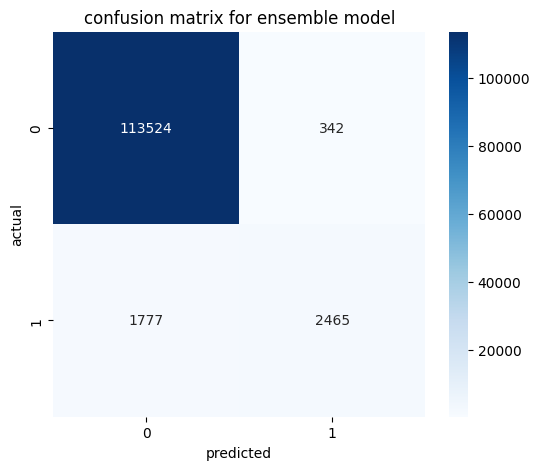

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns 
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, final_prediction)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",cmap="Blues")

plt.title("confusion matrix for ensemble model")
plt.xlabel("predicted")
plt.ylabel("actual")

plt.show()

ROC Curve

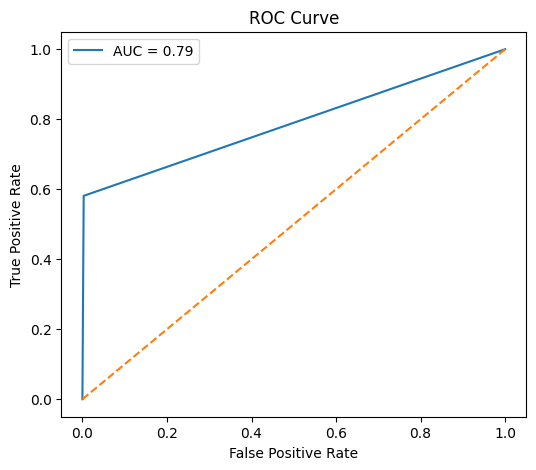

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, final_prediction)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()


feature_importance = pd.Series(
    xgb_balanced.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(20).plot(kind='bar', figsize=(10,5))

plt.title("Top 20 Important Features")
plt.show()

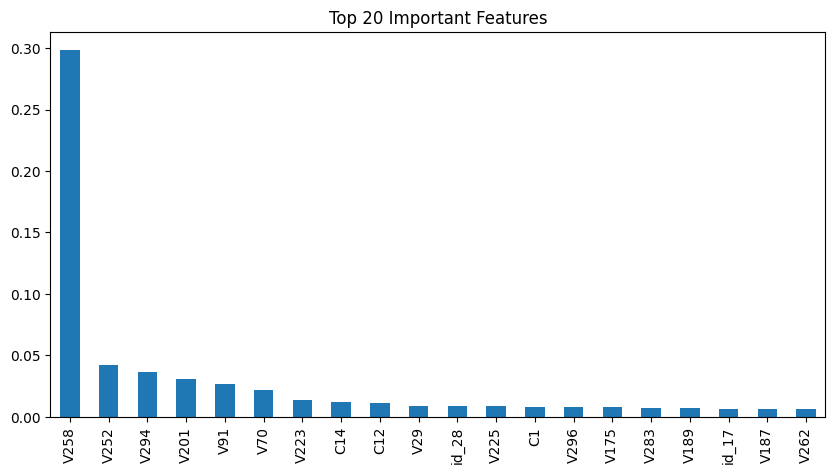

In [47]:
import pandas as pd

feature_importance = pd.Series(
    xgb_1.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(20).plot(kind='bar', figsize=(10,5))

plt.title("Top 20 Important Features")
plt.show()